# INFO 264, Group Exam 2025
### Kandidate numbers: 0000, 0000, 0000, 000
---
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
### <u>Noe av det som står at vi må ha med!!!</u>
#### Important and relevant properties about the data
#### Your preprocessing steps. For example: your process of feature selection and it's results, your choices when it comes to dimension reduction (why/why not/which method/why that method) etc.
#### Based on what you have learnt from the data, why do you think that your models are best-suited for the task
#### Why the particular parameters of a model that you use, work best
#### How you control over- and underfitting
#### Your choice of evaluaon methods. Which metrics did you choose and why? Addionally, you need to give an explanation based on your intuition about why given methods perform better or worse on the given task. 
#### Finally, as a concluding comment in the Jupyter notebook, you need to write a summary of your results, and discuss consequences of such results. 
#### Please provide the list of libraries you use in the form of a `requirements.txt` in the format used by pip. 

===============================-================================

# Task 1 Sentiment Analysis
### a) Exploratory data analysis and prepocessing
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============

Gain a sufficient understanding of the data for
model development and perform data cleaning and feature engineering steps if you find it
necessary. You may make any changes to your dataset; however, you must attempt to give a
reason as to why you find a given transformation necessary. 

===============================-================================

## The data

---
#### <u>Her er bare noen raske tanker om datasettet. Må gåes igjennom og skrives skikkelig!!!</u>
* Hotel_Address -  Not relevant for sentiment labelling. Can be used if we want to base the analysis on different hotels
* Additional_Number_of_Scoring -  Not relevant for sentiment labelling. We dont really know what this scoring is
* Review_Date -  Not relevant for sentiment labelling. Can be used if we want to analyse reviews over time
* Average_Score -  Not relevant for sentiment labelling. Can be used if we want to compare the avarage score of hotels. Combined with Review_Date it can be used to analyse avarage score over time.
* Hotel_Name -  Not relevant for sentiment labelling
* Reviewer_Nationality -  Not relevant for sentiment labelling. Can be used if we want to analyse reviews based on where the reviewer is from
* Negative_Review - Relevant for sentiment labelling. A must use for our purpose
* Review_Total_Negative_Word_Counts - Not really relevant for sentiment labelling
* Total_Number_of_Reviews -  Not relevant for sentiment labelling. Could be used to compare hotels
* Positive_Review - Relevant for sentiment labelling. A must use for our purpose
* Review_Total_Positive_Word_Counts -  Not relevant for sentiment labelling.
* Total_Number_of_Reviews_Reviewer_Has_Given -  Not relevant for sentiment labelling.
* Reviewer_Score - Relevant for sentiment labelling. A must use for our purpose
* Tags -  Not relevant for sentiment labelling.
* Days_since_review -  Not relevant for sentiment labelling.
* lat -  Not relevant for sentiment labelling.
* lng -  Not relevant for sentiment labelling.
 

## Preprocessing steps
---
#### <u>Har bare sett på det vi foreløpig gjør, også skrevet noen ord om det!!!</u>
* Remove unnecessary columns from the dataset
    * Takes in the whole dataset and creates a new dataset with the columns that we need.
* Removing special characters
    * Special characters don't really add any semantic meaning to the text, and they can also increase the vocabulary, because words like "room!" and "room?" will be treated as two different words. We should mention that some special characters like emojis, can carry sentiment meaning. Another example is special characters used in urls or email addresses. This can lead to some unreliable results, but these types of characters are not pressent in our dataset to the point where it would actually affect the results
* Removing single characters
    * Single characters can be typos, don't carry sentiment meaning, and will increase the vocabulary.
* Convert multiple spaces to one space
    * Having consistency with spacing, is important for tokenization
* Removing prefixes
    * Much like special characters, prefixes can increase the vocabulary, but it's important to remember that changing the prefix can also change the meaning of words.
* Convert to lowercase
    * Just as some of the other preprocessing steps, converting to lowercase letters will reduce the vocabulary.
* Lemmatizing words
    * Lemmatizing reduces words to their base, dictionary form. This ensures that words with the similar meaning is treated the same, and it also help the model to better understand the underlying meaning of the words. Lemming will always produce valid words, and consider context and meaning. This is opposed to Stemming, that might produce words that have no meaning, and it does not look at context. It is important to note that lemmatization comes at a cost compared to Stemming, but the increased cost is generally worth it compared to Stemming.
* Removing stopwords
    * Removing words that has no significant sentiment meaning. This also helps with reducing the vocabulary size. Important to note that the standard stopwords package contains words with sentiment meaning. This is something we were wary of, and so we could have added some of those words back.


### Preprocessing setp 1
The function, `csvConverzzion`, takes in the dataset and reads the three columns `Negative_Review`, `Positive_Review` and `Reviewer_Score`. It converts the data to a `NumPy` array to iterate over the rows. The new dataset contains only the necessary columns for our models, and is reordered for consistency.

In [9]:
import pandas as pd
def csvConverzzion(_Path, _sPathNew, _useCols = ["Negative_Review", "Positive_Review", "Reviewer_Score"], _sEncoding = "utf-8"):
    _dataset = pd.read_csv(_Path, usecols = _useCols)
    _mergedReviews = []
    for i in _dataset.to_numpy():
        _mergedReviews.append([ i[2], i[0], i[1] ])
    pd.DataFrame(_mergedReviews, columns = ["Reviewer_Score", "Negative_Review", "Positive_Review"]).to_csv(_sPathNew, encoding = _sEncoding)

csvConverzzion('./data/Hotel_Reviews.csv', "./data/Hotel_Reviews_Reduced.csv")

### Preprocessing step 2
All of our models goes through this step, but the functions used is dependent on the model.
1. <u>The LSTM model uses the following:</u>
    * It uses `combine_reviews` to combine the positive and negative reviews on each row
    * While `combine_reviews` is combining the reviews, it also calls `clean_sentences` on both columns, on each row, to remove special characters, single characters, replaces multiple spaces with one space, removes prefixes, converts to lowercase, lemmatizes the words and removes stopwords. All this is done to get more consistent text, as well as remove unnecessary words that only serve to increase the vocabulary.
    * The `target_score_to_n` function is used to convert the score associated with each review, into one-hot encoded labels `[0, 1, 0]`. This is done to represent the target classes `negative`, `positive` and `neutral`. By converting the classes to numerical arrays, we make them suitable for training. One-hot encoding labels are also needed when using loss functions like `categorical_crossentropy`.
    * This is all done to standardize the text and reduce noice, which helps the LSTM model focus on meaningful patterns

2. <u>The KNN model uses the following:</u>
    * Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt.
    * Ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in. 
    * Voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

3. <u>The NPL model uses the following:</u>
    * Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt.
    * Ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in. 
    * Voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

4. <u>The CNN model uses the following:</u>
    * Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt.
    * Ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in. 
    * Voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

In [10]:
# Importing the default libraries that are needed for the second step in the preprocessing process.
import nltk
# nltk.download('stopwords') # Trenger bare å kjøre første gang
# nltk.download('wordnet') # Trenger bare å kjære første gang
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
import re
from nltk.stem import WordNetLemmatizer

stemmer = WordNetLemmatizer()

In [11]:
# ===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Fjernet Lowercase converting herfra fordi gensim simple_preprocess gjør det by default.
# Fjernet model spesifikke funksjoner ettersom vi kaller de enkle funksjonene når vi trenger dem.
# ===================================================================

# An indenpendent function that cleans the sentences up.
# Returns a list of the cleansed sentences, and the data variable which was used.
def clean_sentences(data):
    all_text = []
    for sen in range(0, len(data)):
        # Remove all the special characters
        text = re.sub(r'\W', ' ', str(data.iloc[sen]))
        # remove all single characters
        text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
        # Remove single characters from the start
        text = re.sub(r'\^[a-zA-Z]\s+', ' ', text) 
        # Substituting multiple spaces with single space
        text = re.sub(r'\s+', ' ', text, flags=re.I)
        # Removing prefixed 'b'
        text = re.sub(r'^b\s+', '', text)
        # Lemmatization
        text = text.split()

        text = [stemmer.lemmatize(word) for word in text if word not in (stop_words)]
        text = ' '.join(text)

        all_text.append(text)
    return all_text

def combine_reviews(data):
    X_1, X_2 = clean_sentences(data["Negative_Review"]), clean_sentences(data["Positive_Review"])
    X = []
    for n in range(len(X_1)):
        X.append(X_1[n] + " " + X_2[n])
    return pd.array(X)

def target_score_to_expression(data):
    y_n = data["Reviewer_Score"].values
    y = []
    for value in y_n:
        if value < 4:
            y.append("negative")
        elif value < 8:
            y.append("neutral")
        else:
            y.append("positive")
        
    return pd.array(y, dtype='object')

# Trenger vi denne? Kan ikke se at den brukes noe sted
def target_score_to_n(data):
    y_n = data["Reviewer_Score"].values
    y = []
    for value in y_n:
        if value < 4:
            y.append([1, 0, 0])
        elif value < 8:
            y.append([0, 1, 0])
        else:
            y.append([0, 0, 1])
     
    return y

### b) Models
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============

Build four (4) machine learning models for labelling sentiment behind hotel reviews.
One of the models needs to be a neural network (e.g. LSTM). You are welcome to train
models that are not covered in the course. Evaluate the performance of the built models
using the appropriate evaluation metrics 

===============================-================================


In [12]:
train = pd.read_csv('./data/Hotel_Reviews_Reduced.csv')

#### Model Imports
All the imports needed for our models

In [13]:
# ===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Fjernet duplikater og ubrukte funksjoner

# ===================================================================

# Importing the necessary libraries for the LSTM model.
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
import tensorflow as tf
import warnings
from gensim.utils import simple_preprocess
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras import layers, datasets, models, callbacks
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
warnings.filterwarnings('ignore')

Combine the negative and positive reivew column on each row. During the combining process, the words are also cleaned by removing special characters, single characters, multiple spaces, prefixes and at the end it also lemmatizes the words.

In [14]:
X = combine_reviews(train)
y = target_score_to_expression(train)

This next preprocessing step removes all numbers and converts to lowercase.

In [15]:
def sent_to_words(sentences):
    for sentence in sentences:
        yield(simple_preprocess(str(sentence)))
        
data_words = list(sent_to_words(X))
data = np.array([" ".join(words) for words in data_words])

One-hot encode the labels

In [16]:
labels = np.array(y)
y = []
for i in range(len(labels)):
    if labels[i] == 'neutral':
        y.append(0)
    if labels[i] == 'negative':
        y.append(1)
    if labels[i] == 'positive':
        y.append(2)
y = np.array(y)
labels = tf.keras.utils.to_categorical(y, num_classes=3)

In [17]:
# ===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Med fullført preprocessing så har vi følgende mengde ord:
# 10331478 ord
# 73439 unike ord
# 18941 ord forekommer 5 ganger eller mer
# 95% av reviews er 55 ord eller færre 
# ===================================================================

#### LSTM Model
For faster training, we have opted to use tensorflow with a GPU

Tokenizing and padding

In [18]:
max_words = 5000
max_len = 55

tokenizer = Tokenizer(num_words = max_words)
tokenizer.fit_on_texts(data)
sequences = tokenizer.texts_to_sequences(data)
reviews = pad_sequences(sequences, maxlen = max_len)

X_train_LSTM, X_test_LSTM, y_train_LSTM, y_test_LSTM = train_test_split(reviews, labels, random_state = 0)

Training the LSTM model

In [19]:
with tf.device('/GPU:0'):
    model1 = Sequential()
    model1.add(layers.Embedding(max_words, 20))
    model1.add(layers.Masking(mask_value=0))
    model1.add(layers.LSTM(20,dropout=0.3, return_sequences=False))
    model1.add(layers.Dense(3,activation='softmax'))
    model1.compile(optimizer='rmsprop',loss='categorical_crossentropy', metrics=['accuracy'])

    # Implementing model checkpoins to save the best metric and do not lose it on training.
    checkpoint1 = ModelCheckpoint("best_model1.keras", monitor='val_accuracy', verbose=1,save_best_only=True, mode='auto',save_weights_only=False)
    history = model1.fit(X_train_LSTM, y_train_LSTM, epochs=10, batch_size=512,validation_data=(X_test_LSTM, y_test_LSTM),callbacks=[checkpoint1])

Epoch 1/10
756/756 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7139 - loss: 0.6297
Epoch 1: val_accuracy improved from -inf to 0.77436, saving model to best_model1.keras
756/756 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.7140 - loss: 0.6296 - val_accuracy: 0.7744 - val_loss: 0.5022
Epoch 2/10
755/756 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7795 - loss: 0.4907
Epoch 2: val_accuracy improved from 0.77436 to 0.78493, saving model to best_model1.keras
756/756 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.7795 - loss: 0.4906 - val_accuracy: 0.7849 - val_loss: 0.4766
Epoch 3/10
755/756 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7876 - loss: 0.4748
Epoch 3: val_accuracy improved from 0.78493 to 0.78637, saving model to best_model1.keras
756/756 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.7876 - loss: 0.4748 - val_accuracy: 0.7864 - val_loss: 0.4721
Epoch 4/10
755/756 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7894 - loss: 0.4684
Epoch 4: val_accuracy improv

In [20]:
# Load the best model obtained during training
best_model_LSTM = keras.models.load_model("best_model1.keras")

In [21]:
test_loss_LSTM, test_acc_LSTM = best_model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose=2)
print('Model accuracy: ',test_acc_LSTM)

4030/4030 - 12s - 3ms/step - accuracy: 0.7928 - loss: 0.4595
Model accuracy:  0.7927560210227966


In [22]:
predictions = best_model_LSTM.predict(X_test_LSTM)
matrix = confusion_matrix(y_test_LSTM.argmax(axis=1), np.around(predictions, decimals=0).argmax(axis=1))
print(classification_report(np.argmax(y_test_LSTM, axis=1), np.argmax(predictions, axis=1)))

4030/4030 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
              precision    recall  f1-score   support

           0       0.72      0.62      0.66     42265
           1       0.65      0.25      0.36      2673
           2       0.83      0.90      0.86     83997

    accuracy                           0.79    128935
   macro avg       0.73      0.59      0.63    128935
weighted avg       0.79      0.79      0.79    128935



<Axes: >

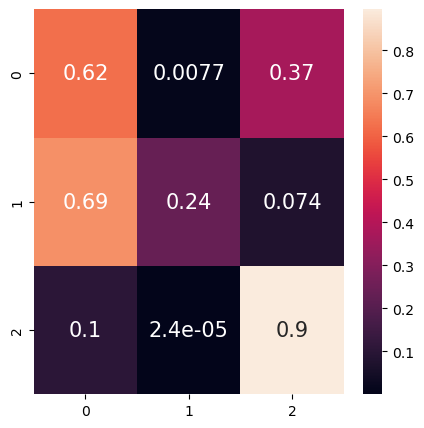

In [23]:
conf_matrix = pd.DataFrame(matrix, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])

# Normalizing
conf_matrix = np.array(conf_matrix).astype('float') / np.array(conf_matrix).sum(axis=1)[:, np.newaxis]
plt.figure(figsize = (5,5))
sns.heatmap(conf_matrix, annot=True, annot_kws={"size": 15})

#### KNN Model
Convert the one-hot encoded labels to a 1D array

In [24]:
labels_convert_KNN = np.argmax(labels, axis=1)

Vectorizing the reviews

In [25]:
vectorizer = TfidfVectorizer(max_features = 5000, ngram_range = (1, 1), min_df = 5)
vectorize_reviews = vectorizer.fit_transform(data) 

Split the data into training and testing sets. Testing on 20% of the data with a random state at 42 because that's the answer to life, the universe, and everything

In [26]:
X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(vectorize_reviews, labels_convert_KNN, test_size = 0.2, random_state = 42)

In [27]:
k = 3
knn = KNeighborsClassifier(n_neighbors = k)
knn.fit(X_train_KNN, y_train_KNN)
y_pred_train = knn.predict(X_train_KNN)
y_pred_test = knn.predict(X_test_KNN)

KeyboardInterrupt: 

In [ ]:
matrix = sklearn.metrics.confusion_matrix(y_pred_test, y_test_KNN)

train_accuracy = accuracy_score(y_train_KNN, y_pred_train)
test_accuracy = accuracy_score(y_test_KNN, y_pred_test)
overfitting = train_accuracy - test_accuracy

In [ ]:
print("k = 3")
print(matrix)
print(f'train_accuracy: {train_accuracy}')
print(f'test_accuract: {test_accuracy}')
print(f'overfitting: {overfitting}')
print("--------------------------------------------------")

k = 3
[[ 6930   424  5856]
 [   81    79    27]
 [26989  1662 61100]]
train_accuracy: 0.7276521486221188
test_accuract: 0.6603036413696824
overfitting: 0.06734850725243635
--------------------------------------------------


#### NLP Model

In [ ]:
cv = CountVectorizer()
X = cv.fit_transform(X)
y_nlp = target_score_to_expression(train)

X_train_NLP, X_test_NLP, y_train_NLP, y_test_NLP = train_test_split(X, y_nlp, test_size=0.2, random_state=0)

In [29]:
bnb = BernoulliNB(binarize=0)
model_NLP = bnb.fit(X_train_NLP, y_train_NLP)
y_pred_NLP = bnb.predict(X_test_NLP)
print("BernoulliNB: ")
print(classification_report(y_test_NLP, y_pred_NLP))

BernoulliNB: 
              precision    recall  f1-score   support

           0       0.61      0.50      0.55     33825
           1       0.19      0.24      0.21      2113
           2       0.78      0.85      0.81     67210

    accuracy                           0.72    103148
   macro avg       0.53      0.53      0.52    103148
weighted avg       0.71      0.72      0.71    103148



MultinomialNB: 
              precision    recall  f1-score   support

           0       0.61      0.50      0.55     33825
           1       0.19      0.24      0.21      2113
           2       0.78      0.85      0.81     67210

    accuracy                           0.72    103148
   macro avg       0.53      0.53      0.52    103148
weighted avg       0.71      0.72      0.71    103148



<Axes: >

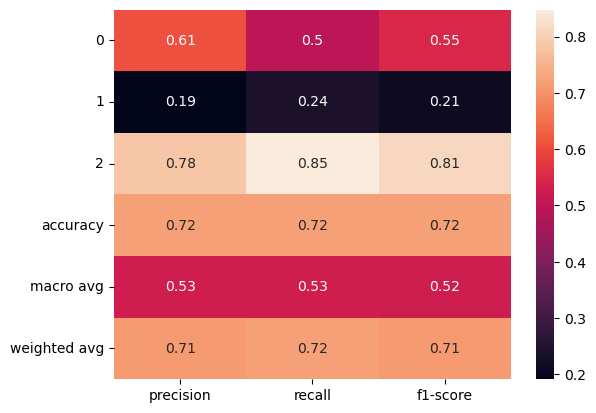

In [30]:
print("MultinomialNB: ")
model_NLP = MultinomialNB()
model_NLP.fit(X_train_NLP, y_train_NLP)
y_pred = model_NLP.predict(X_test_NLP) 
clf_report = classification_report(y_test_NLP, y_pred_NLP, output_dict=True)
print(classification_report(y_test_NLP, y_pred_NLP))

sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)

#### CNN Model

# Task 2 Convolution Neural Network

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

from tensorflow.keras.utils import to_categorical
train_labels_TEST = to_categorical(train_labels)
test_labels_TEST = to_categorical(test_labels)

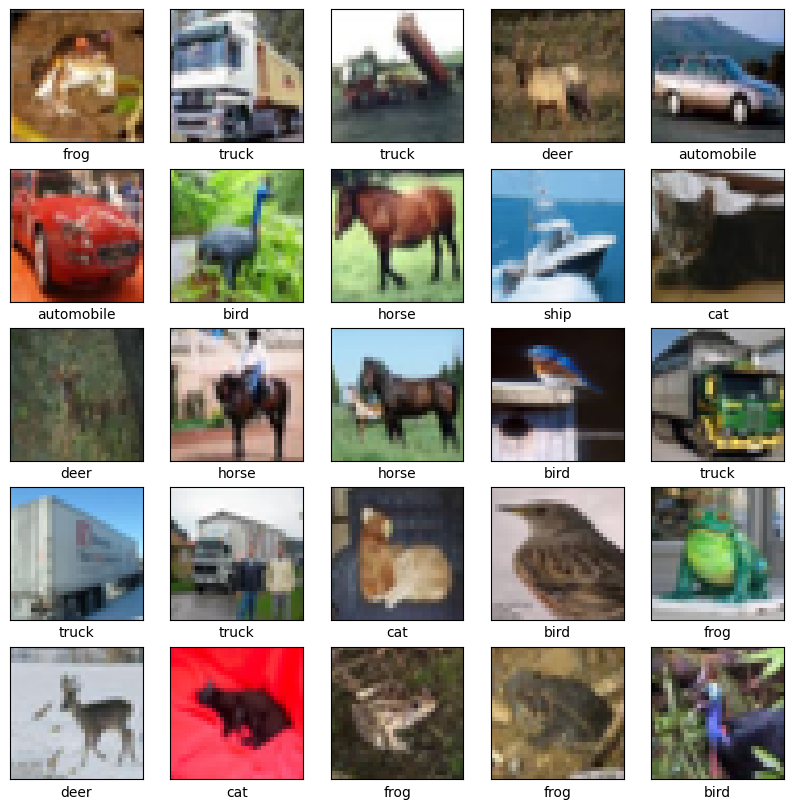

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [ ]:
with tf.device('/GPU:0'):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(256, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience = 5, restore_best_weights = True)

    history = model.fit(
        train_images,
        train_labels_TEST,
        batch_size = 64,
        epochs = 50,
        validation_data = (test_images, test_labels_TEST),
        callbacks = [early_stopping]
    )

# model.summary()

Epoch 1/50
782/782 [==============================] - 3s 4ms/step - loss: 2.6445 - accuracy: 0.4700 - val_loss: 1.8397 - val_accuracy: 0.5271
Epoch 2/50
782/782 [==============================] - 3s 3ms/step - loss: 1.4572 - accuracy: 0.6394 - val_loss: 1.8586 - val_accuracy: 0.5007
Epoch 3/50
782/782 [==============================] - 3s 3ms/step - loss: 1.2709 - accuracy: 0.6969 - val_loss: 1.2822 - val_accuracy: 0.6839
Epoch 4/50
782/782 [==============================] - 3s 3ms/step - loss: 1.2012 - accuracy: 0.7289 - val_loss: 1.4613 - val_accuracy: 0.6344
Epoch 5/50
782/782 [==============================] - 3s 3ms/step - loss: 1.1454 - accuracy: 0.7562 - val_loss: 1.4906 - val_accuracy: 0.6506
Epoch 6/50
782/782 [==============================] - 2s 3ms/step - loss: 1.1044 - accuracy: 0.7766 - val_loss: 1.6250 - val_accuracy: 0.6310
Epoch 7/50
782/782 [==============================] - 3s 3ms/step - loss: 1.0698 - accuracy: 0.7918 - val_loss: 1.2175 - val_accuracy: 0.7396
Epoch 

In [ ]:
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# history = model.fit(train_images, train_labels_TEST, epochs=30, validation_data=(test_images, test_labels_TEST))

313/313 - 1s - loss: 1.2175 - accuracy: 0.7395 - 605ms/epoch - 2ms/step


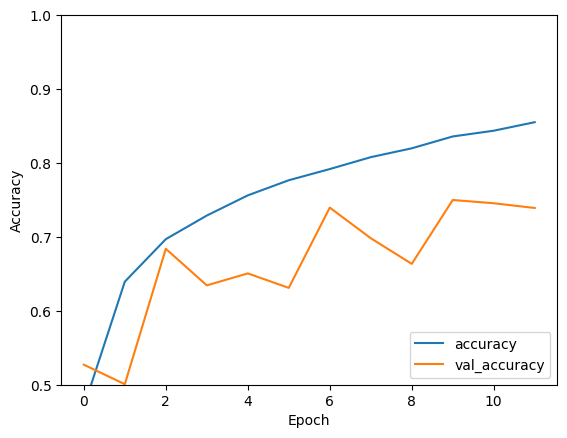

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels_TEST, verbose=2)

In [ ]:
from tensorflow.keras import Model
from tensorflow.keras.optimizers import RMSprop
model.trainable = False

x = layers.GlobalAveragePooling2D()(model.output)
x = layers.Dense(1, activation='sigmoid')(x)

r_model = Model(model.input, x)
r_model.compile(loss='binary_crossentropy', optimizer=RMSprop(lr=0.001), metrics=['acc'])

from tensorflow.keras.callbacks import Callback
class mycallback(Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get('loss') <= 0.09:
            self.model.stop_training = True
        if logs.get('acc') <= 1.00:
            self.model.stop_training = True

callbacks = [mycallback()]
history = r_model.fit_generator(
    train_images,
    train_labels_TEST,
    batch_size = 64,
    epochs = 50,
    validation_data = (test_images, test_labels_TEST),
    callbacks = callbacks,
    verbose = 2
    )

In [ ]:
# Defining dependent variables for plotting
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
# Defining independent variable for plotting
epochs = range(len(acc))
# Creating grid of subplots
fit, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.axes_style('whitegrid')
# Plotting accuracy
sns.lineplot(x=epochs,
             y=acc,
             color='r',
             label='Training accuracy',
             ax=axes[0])
sns.lineplot(x=epochs,
             y=val_acc,
             color = 'b',
             label='Validation accuracy',
             ax=axes[0])
# Plotting loss
sns.lineplot(x=epochs,
             y=loss,
             color='r',
             label='Training loss',
             ax=axes[1])
sns.lineplot(x=epochs,
             y=val_loss,
             color = 'b',
             label='Validation loss',
             ax=axes[1])
plt.tight_layout()
plt.show();

In [ ]:
img = tf.keras.utils.load_img('./media/dog_2.jpg', target_size=(32, 32))

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch
prediction = model.predict(img_array)
print(class_names[np.argmax(prediction)])

1/1 [==============================] - 0s 43ms/step
dog
